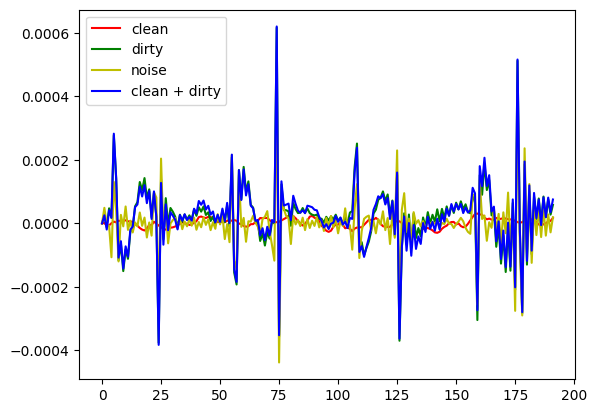

In [1]:
import numpy as np
import matplotlib.pyplot as plt

clean = np.load('data_segmented/16/clean.npy')
dirty = np.load('data_segmented/16/dirty.npy')
noise = np.load('data_segmented/16/noise.npy')

# Plotting both the curves simultaneously
plt.plot(clean[0,0,:], color='r', label='clean')
plt.plot(dirty[0,0,:], color='g', label='dirty')
plt.plot(noise[0,0,:], color = 'y', label='noise')
plt.plot(clean[0,0,:] + dirty[0,0,:], color='b', label='clean + dirty')

# Adding legend, which helps us recognize the curve according to it's color
plt.legend()

# To load the display window
plt.show()

In [3]:
dirty.shape

(11907, 26, 192)

Device used: cpu

Visualizing predictions from best model...


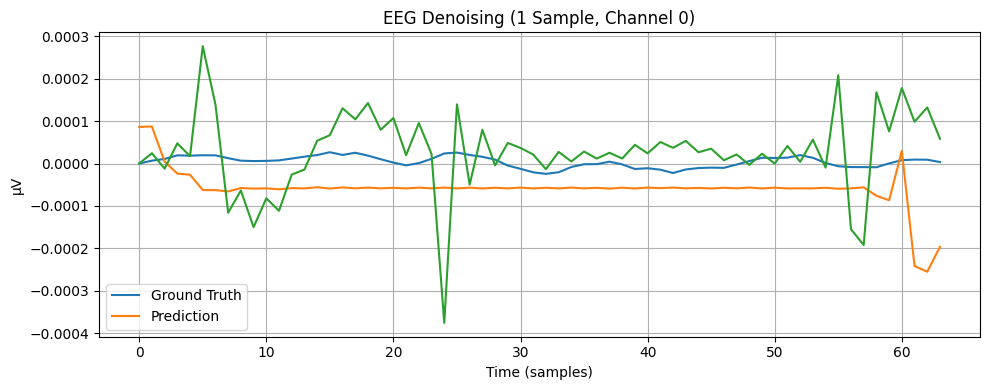

In [ ]:
import torch
from resunet import DeepDSP_UNetRes


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device used:", device)
print("\nVisualizing predictions from best model...")

model = DeepDSP_UNetRes().to(device)
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

with torch.no_grad():
    ch, win = 0, 0                           # channel & epoch index
    x  = np.stack([dirty[win, ch], noise[win, ch]], axis=0).astype(np.float32)

    m  = x.mean()
    sd = x.std() + 1e-8
    x_norm = (x - m) / sd

    x_t = torch.from_numpy(x_norm).unsqueeze(0).to(device)   # [1,2,T]
    y_t = torch.from_numpy(clean[win, ch])[None, None].to(device)
    y_norm = (y_t - m) / sd

    pred_n     = model(x_t)
    cleaned_n  = x_t[:, 0:1, :] - pred_n     # normalised cleaned

    # -------- denormalise & move to CPU ----------
    dirty_v   = (x_t[:,0].cpu().numpy()      * sd + m).squeeze()
    cleaned_v = (cleaned_n.cpu().numpy()     * sd + m).squeeze()
    gt_clean  = (y_norm.cpu().numpy()        * sd + m).squeeze()

    # -------- plot ----------
    t = np.arange(dirty_v.shape[-1])
    plt.figure(figsize=(10,4))
    plt.plot(t, gt_clean,  label="Ground-truth clean")
    plt.plot(t, cleaned_v, label="Model cleaned")
    plt.plot(t, dirty_v,   label="Dirty (input)", alpha=.4)
    plt.xlabel("Time (samples)"); plt.ylabel("Amplitude (µV)")
    plt.title(f"EEG denoising — ch {ch}, window {win}")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [11]:
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
import torch


# ───────────────────────────────────────────────
#                Dataset definition
# ───────────────────────────────────────────────
class EEGDenoiseDataset(Dataset):
    def __init__(self, root_dir: str | Path):
        self.samples = []
        root_dir = Path(root_dir)

        for subj in sorted(root_dir.glob("*")):
            if not subj.is_dir():
                continue
            try:
                clean = np.load(subj / "clean.npy")    # shape: (N, ch, T)
                noise = np.load(subj / "noise.npy")
                dirty = np.load(subj / "dirty.npy")
            except FileNotFoundError as e:
                print(f"Skipping {subj.name}: {e}")
                continue

            for d_ep, n_ep, c_ep in zip(dirty, noise, clean):
                for ch in range(d_ep.shape[0]):
                    x = np.stack([c_ep[ch]+n_ep[ch], n_ep[ch]], axis=0)  # (2, T)
                    y = c_ep[ch][None, ...]                    # (1, T)
                    self.samples.append((x.astype(np.float32),
                                          y.astype(np.float32)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]

        # Normalize per-sample (z-score)
        def normalize(z):
            mean = z.mean(axis=1, keepdims=True)
            std  = z.std(axis=1, keepdims=True) + 1e-8
            return (z - mean) / std

        x = normalize(x)
        #y = normalize(y)

        return torch.from_numpy(x), torch.from_numpy(y)

# Load dataset and split by sample
dataset = EEGDenoiseDataset('data_segmented/')
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0, drop_last=True, pin_memory=True)


In [ ]:
x,y = next(iter(loader))

c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


torch.Size([32, 2, 192])

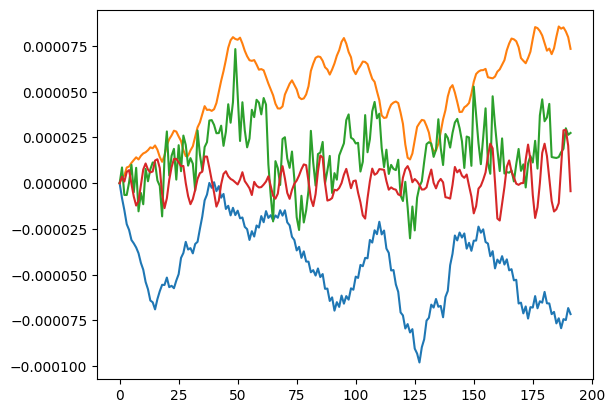

In [ ]:
# Y --> [batch_size, 1, T]
plt.plot(y[0,0,:])
plt.plot(y[1,0,:])
plt.plot(y[2,0,:])
plt.plot(y[3,0,:])